<a href="https://colab.research.google.com/github/zelal-Eizaldeen/deeplearning_course/blob/main/8_1Qwen_KV_Cache.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Before working with a model—especially an LLM—it’s a common and **recommended practice to inspect its configuration**. A model’s configuration contains valuable details about its architecture, such as the number of layers, hidden dimensions, attention heads, vocabulary size, and more.

Understanding this information helps you estimate the compute resources required (such asGPU memory), choose appropriate model-serving strategies (like quantization or batching), andplan for performance optimization (for instance, layer-wise parallelism or model sharding).

In [1]:
!pip install --quiet transformers tiktoken transformers_stream_generator bertviz


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 157.5/157.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 4.1 MB/s eta 0:00:00


In [2]:
import torch
import gc
import time

# Unload models and clean up gpu memory cache
def free_gpu(model):
  if model:
    # Removes the reference to the model's memory,
    # making it eligible for garbage collection.
    del model

  # Release any cached GPU memory that's no longer needed.
  torch.cuda.empty_cache()

  # Trigger garbage collection to ensure memory is fully released.
  gc.collect()


In [3]:
from transformers import AutoModelForCausalLM
from pprint import pprint

model_name = "Qwen/Qwen2.5-0.5B"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    device_map="auto"
)

# Print all configuration parameters
config = model.config
print("\n=== Model Configuration Parameters ===")

# Architecture parameters
print("\nArchitecture Parameters:")
print(f"Hidden size: {config.hidden_size}")  # Size of the hidden layers
print(f"Number of layers: {config.num_hidden_layers}")  # Number of transformer blocks
print(f"Number of attention heads: {config.num_attention_heads}")  # Number of attention heads
print(f"Intermediate size: {config.intermediate_size}")  # Size of the MLP intermediate layer

# Tokenizer parameters
print("\nTokenizer Parameters:")
print(f"Vocabulary size: {config.vocab_size}")  # Size of the vocabulary
print(f"Maximum position embeddings: {config.max_position_embeddings}")  # Maximum sequence length

# Print model size
total_params = sum(p.numel() for p in model.parameters())
print(f"\nModel Size:")
print(f"Total parameters: {total_params:,}")

# Model-specific parameters
print("\nModel-specific Parameters:")
for key, value in config.to_dict().items():
    if key not in ['architectures', 'model_type', 'torch_dtype']:
        print(f"{key}: {value}")

# Free GPU memory
free_gpu(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]


=== Model Configuration Parameters ===

Architecture Parameters:
Hidden size: 896
Number of layers: 24
Number of attention heads: 14
Intermediate size: 4864

Tokenizer Parameters:
Vocabulary size: 151936
Maximum position embeddings: 32768

Model Size:
Total parameters: 494,032,768

Model-specific Parameters:
vocab_size: 151936
max_position_embeddings: 32768
hidden_size: 896
intermediate_size: 4864
num_hidden_layers: 24
num_attention_heads: 14
use_sliding_window: False
sliding_window: None
max_window_layers: 24
num_key_value_heads: 2
hidden_act: silu
initializer_range: 0.02
rms_norm_eps: 1e-06
use_cache: True
rope_theta: 1000000.0
rope_scaling: None
attention_dropout: 0.0
layer_types: ['full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention', 'full_attention',

#Summary
What is model.config? It's a configuration object that contains all the hyperparameters and settings of the model It defines the model's architecture, size, and behavior It's essentially a blueprint of how the model is structured

# Executing LLM Generation: Step-by-Step Walkthrough

In this section, we’ll take you behind the scenes of how a LLM generates tokens—step by step. We believe the most effective way to understand the performance challenges of LLM serving is through hands-on, incremental execution, observing how tokens are generated one at a time.

# Run the Qwen model

To get started easily, let’s run the Qwen 2.5 model using the Hugging Face pipeline library. This is the simplest way to use an LLM, as the pipeline object abstracts away much of the underlying complexity and provides a straightforward generator() API for text generation.

This code loads the Qwen 2.5 model and generates text using generator(prompt, ...). For the input prompt “Write a short introduction about the US capital city,

In [4]:
from transformers import pipeline
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Initialize the text generation pipeline
generator = pipeline('text-generation', model='Qwen/Qwen2.5-0.5B')

# Define your prompt
prompt = "Write a short introduction about US capital city."

# Generate text
generated_text = generator(prompt, max_length=50, num_return_sequences=1)

# Print the generated text
print(generated_text[0]['generated_text'])

free_gpu(generator.model)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0
Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.
Both `max_new_tokens` (=256) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Write a short introduction about US capital city. Washington, D.C. is the capital city of the United States. It is located in the nation's capital, which is located on the Northeastern border of the country. Washington, D.C., is the seat of the federal government and is home to many important institutions of higher learning and government. The city is also known for its famous monuments, including the Lincoln Memorial and the Washington Monument. The city is also home to many museums and historic sites, including the White House, the Smithsonian Institution, and the National Mall.


# Implementing Qwen token generation, token by token
**S1**, we need to specify the model and load tokenizer. Here, instead of using pipeline, we use **AutoModelForCausalLM** to load the Qwen 2.5 model. It offers full control over the generation configuration, inputs, and decoding strategies—making it the ideal choice when we want to manually prepare inputs and handle the generation process step by step.

**S2**, define the input prompt.

**S3** Convert (Tokenize) prompt to the input format that model understands

**S4**  We start the main generation loop, generating tokens one by one. Notice that outputs = model(idx_cond), at step 4(B), runs the Qwen model and produces candidates for the new token, given the input idx_cond, while logits = outputs.logits gets the logits, or raw prediction scores, for each token prediction:

**C** The model selects the next token from the predictions it just generated:



In [ ]:
import torch
import time
from transformers import AutoTokenizer, AutoModelForCausalLM

first_token_generated = False

# (1) Specify the model and load tokenizer and model
model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True).to("cuda" if torch.cuda.is_available() else "cpu")

# (2) Define the input prompt - a text about communication history
prompt = """The history of human communication is a story of innovation. From ancient cave paintings and spoken language to the invention of writing systems, humans have constantly developed new methods to express ideas and share knowledge. The printing press revolutionized the spread of information, enabling books to be produced and distributed at an unprecedented scale. Centuries later, the invention of the telegraph, radio, and television further transformed how we connect with one another. But perhaps no advancement has reshaped communication more profoundly than the internet.
Today, digital platforms allow billions of people to share messages, media, and experiences in real time. Social media, messaging apps, and video conferencing have broken down geographical barriers and created new ways of building communities. At the same time, these technologies raise important questions about privacy, information overload, and the nature of human interaction.
Looking ahead, emerging technologies such as virtual reality, brain-computer interfaces, and artificial intelligence promise to once again redefine how we communicate. As we reflect on this history and anticipate the future, one question arises:

How might the next wave of communication tools shape our relationships, societies, and sense of identity?"""

# (3) Convert (Tokenize) prompt to the input format that model understands
max_new_tokens = 100
# tokenize the input prompt for the first output token
# PS: prompt is the initial input sequence for LLM generation
idx = tokenizer(prompt, return_tensors="pt").input_ids.to(model.device)
start_time = total_time = time.time()
times = []

# (4) Main generation loop - generate tokens one by one
for _ in range(max_new_tokens):

    # (A) Set the current context for generation
    idx_cond = idx
    with torch.no_grad():
        # (B) Generate predictions (token candidates) for next token
        outputs = model(idx_cond)
        # Get the logits (raw prediction scores) for each token predictions
        logits = outputs.logits

    # (C) Select next token from the predictions generated in step (B)
    logits = logits[:, -1, :] #  Select only the logits for the last token
    probas = torch.softmax(logits, dim=-1) # Convert logits to probabilities using softmax
    # Sample the next token from the probability distribution of the predicted tokens from step (B)
    idx_next = torch.multinomial(probas, num_samples=1)
    print("Next Token is:", tokenizer.decode(idx_next[0], skip_special_tokens=True))
    time_cost = time.time() - start_time
    times.append(time_cost)

    # Track time spent in token generation
    if not first_token_generated:
        print(f"Time taken for generating the first token: {time_cost:.4f} seconds")
        first_token_generated = True
    else:
        print(f"Time taken for generating a token: {time_cost:.4f} seconds")

    start_time = time.time()

    # (D) Append the new token to the input sequence
    idx = torch.cat((idx, idx_next), dim=1)

    # (E) Check if end-of-sequence token was generated
    if idx_next.item() == tokenizer.eos_token_id:
        print("\n[Generation completed - EOS token reached]")
        break

# Decode the entire generated sequence
generated_text = tokenizer.decode(idx[0], skip_special_tokens=True)
print(f"Total time take for next token: {time.time() - total_time:.4f} seconds")
print(generated_text)

# Free GPU memory
free_gpu(model=model)

In addition to demonstrating the code, we also tracked the latency of each token during the generation process.

Text(0.5, 1.0, 'LLM Generation Times for each token')

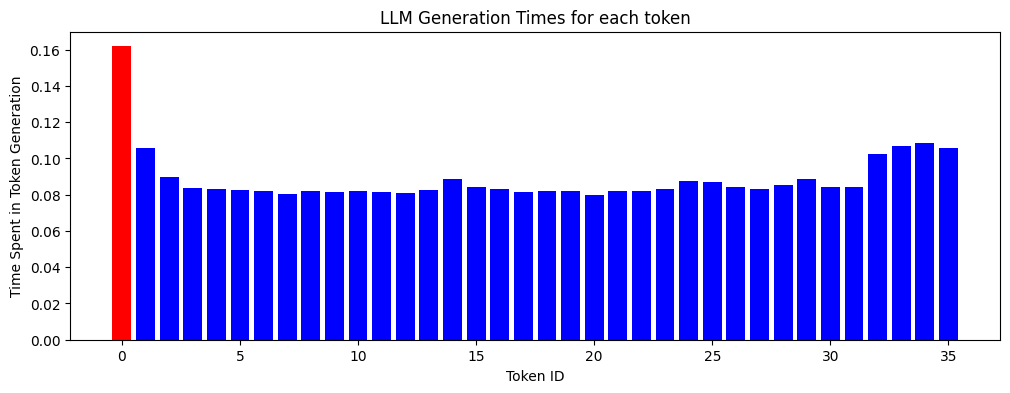

In [6]:
import matplotlib.pyplot as plt

# First chart: First bar red, others blue
plt.figure(figsize=(12, 4))
# plt.subplot(1, 2, 1)
plt.bar(range(len(times)), times, color=['red'] + ['blue'] * (len(times) - 1))
plt.xlabel("Token ID")
plt.ylabel("Time Spent in Token Generation")
plt.title("LLM Generation Times for each token")


# # Second chart: Exclude the first element
# plt.subplot(1, 2, 2)
# plt.bar(range(len(times) - 1), times[1:])
# plt.xlabel("Token ID")
# plt.ylabel("Time Spent in Token Generation")
# plt.title("Token Generation Times (Excluded the initial prompt tokens)")

# plt.tight_layout()
# plt.show()

# KV Cache
As machine learning engineers, we can quickly recognize the inefficiency the model recomputes attention for all previous tokens every time a new token is generated. This repetitive computation over known tokens is costly and unnecessary. Can we avoid recalculating the same attention for previous tokens and instead focus computation on the newly generated one?
This brings us to the next topic—the concept of KV Cache.

the key-value (KV) cache does: this optimization stores the attention keys and values computed at each layer for previously generated tokens, allowing the model to skip redundant computations during decoding

the KV cache shifts the LLM calculation from full-sequence recomputation to an incremental, cache-augmented workflow—trading increased memory usage for significant compute savings.This technique dramatically reduces redundant computation and enables much faster token generation.

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True, use_cache=True) \
            .to("cuda" if torch.cuda.is_available() else "cpu")

model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True).to("cuda" if torch.cuda.is_available() else "cpu")

prompt = """The history of human communication is a story of innovation. From ancient cave paintings and spoken language to the invention of writing systems, humans have constantly developed new methods to express ideas and share knowledge. The printing press revolutionized the spread of information, enabling books to be produced and distributed at an unprecedented scale. Centuries later, the invention of the telegraph, radio, and television further transformed how we connect with one another. But perhaps no advancement has reshaped communication more profoundly than the internet.
Today, digital platforms allow billions of people to share messages, media, and experiences in real time. Social media, messaging apps, and video conferencing have broken down geographical barriers and created new ways of building communities. At the same time, these technologies raise important questions about privacy, information overload, and the nature of human interaction.
Looking ahead, emerging technologies such as virtual reality, brain-computer interfaces, and artificial intelligence promise to once again redefine how we communicate. As we reflect on this history and anticipate the future, one question arises:

How might the next wave of communication tools shape our relationships, societies, and sense of identity?"""

num_interations = 100
times_with_cache = []

first_token_generated = False
input_ids = tokenizer(prompt, return_tensors="pt").input_ids.to(model.device)
idx = input_ids
start_time = total_time = time.time()

# (1) Define Key/Value Cache for faster generation
past_key_values = None

for _ in range(num_interations):
    print("input_ids size: " + str(input_ids.size()))
    with torch.no_grad():
        outputs = model(input_ids=input_ids,
          past_key_values=past_key_values, # (2) Use KV-cache from previous iteration
          use_cache=True, # (2) Enable KV caching
          max_new_tokens = 100,
          min_new_tokens= 100)


        logits = outputs.logits
        # (3) Update KV Cache
        past_key_values = outputs.past_key_values
        torch.cuda.synchronize()

    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1)
    generated_token_id = torch.multinomial(probas, num_samples=1) # Sample instead of argmax

    # (4) Update input_ids with only the new token (using KV-cache)
    input_ids = generated_token_id  # Note: Not concatenating with previous tokens due to KV-cache

    print("Next token:", tokenizer.decode(generated_token_id[0], skip_special_tokens=True))
    idx = torch.cat((idx, generated_token_id), dim=1)

    time_cost= time.time() - start_time
    times_with_cache.append(time_cost)
    if not first_token_generated:
        print(f"Time take for first token: {time_cost:.4f} seconds")
        first_token_generated = True
    else:
        print(f"Time take for next token: {time_cost:.4f} seconds")
    start_time = time.time()

    if generated_token_id.item() == tokenizer.eos_token_id:
        print("\n[Generation completed - EOS token reached]")
        break

generated_text = tokenizer.decode(idx[0], skip_special_tokens=True)
print(f"Total time take for next token: {time.time() - total_time:.4f} seconds")
print(generated_text)

free_gpu(model=model)


<Figure size 1200x800 with 0 Axes>

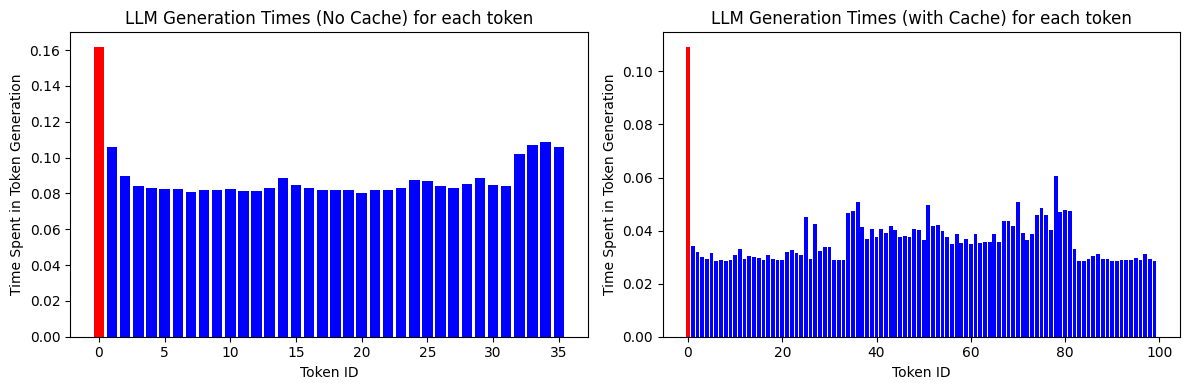

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Display the time cost of LLM token generation without KV Cache
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.bar(range(len(times)), times, color=['red'] + ['blue'] * (len(times) - 1))
plt.xlabel("Token ID")
plt.ylabel("Time Spent in Token Generation")
plt.title("LLM Generation Times (No Cache) for each token")


# Display the time cost of LLM token generation with KV Cache
plt.subplot(1, 2, 2)
plt.bar(range(len(times_with_cache)), times_with_cache, color=['red'] + ['blue'] * (len(times_with_cache) - 1))
plt.xlabel("Token ID")
plt.ylabel("Time Spent in Token Generation")
plt.title("LLM Generation Times (with Cache) for each token")

plt.tight_layout()
plt.show()


In [ ]:
import torch
import time
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-0.5B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True)\
          .to("cuda" if torch.cuda.is_available() else "cpu")

prompt = """The history of human communication is a story of innovation. From ancient cave paintings and spoken language to the invention of writing systems, humans have constantly developed new methods to express ideas and share knowledge. The printing press revolutionized the spread of information, enabling books to be produced and distributed at an unprecedented scale. Centuries later, the invention of the telegraph, radio, and television further transformed how we connect with one another. But perhaps no advancement has reshaped communication more profoundly than the internet.
Today, digital platforms allow billions of people to share messages, media, and experiences in real time. Social media, messaging apps, and video conferencing have broken down geographical barriers and created new ways of building communities. At the same time, these technologies raise important questions about privacy, information overload, and the nature of human interaction.
Looking ahead, emerging technologies such as virtual reality, brain-computer interfaces, and artificial intelligence promise to once again redefine how we communicate. As we reflect on this history and anticipate the future, one question arises:

How might the next wave of communication tools shape our relationships, societies, and sense of identity?"""

max_new_tokens = 50
context_size = 2048 # Define the context size as needed for Qwen

first_token_generated = False
idx = tokenizer(prompt, return_tensors="pt").input_ids.to(model.device)
start_time = total_time = time.time()

for _ in range(max_new_tokens):
    # Take the latest "context_size" tokens as model input
    idx_cond = idx[:, -context_size:]
    with torch.no_grad():
        outputs = model(idx_cond)
        logits = outputs.logits

    # select next token from candidates based on probabilities.
    logits = logits[:, -1, :]
    probas = torch.softmax(logits, dim=-1)
    idx_next = torch.multinomial(probas, num_samples=1)
    print("Decode text generated:", tokenizer.decode(idx_next[0], skip_special_tokens=True))

    idx = torch.cat((idx, idx_next), dim=1)

    if idx_next.item() == tokenizer.eos_token_id:
        print("\n[Generation completed - EOS token reached]")
        break

generated_text = tokenizer.decode(idx[0], skip_special_tokens=True)
print(f"Total time take for next token: {time.time() - total_time:.4f} seconds")
print(generated_text)

# Free GPU memory
free_gpu(model=model)